A researcher is interested in how variables, such as GRE(Graduate Record Exam scores), GPA(Grade point average) and prestige of the undergraduate institution, effect admisssion into graduate school. The response variable, admit/ don't admit, is a binary variable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [4]:
import requests

requests.get("https://www.google.com")

<Response [200]>

In [5]:
url = "https://stats.idre.ucla.edu/stat/data/binary.csv"
df = pd.read_csv(url)

df.head()

,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


In [6]:
print("SHAPE:",df.shape)
print("\n", df.isnull().sum())

SHAPE: (400, 4)

 admit    0
gre      0
gpa      0
rank     0
dtype: int64


In [8]:
# separating the features and target
X = df[['gre', 'gpa', 'rank']]
y = df['admit']


#one-hot encoding university rank
X = pd.get_dummies(
    X,
    columns=['rank'],
    drop_first=True,
    dtype=int
)

In [9]:
# train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
#create and train logistic regression 
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


In [16]:
# Evaluation

print("\nMODEL EVALUATION")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))


MODEL EVALUATION
Accuracy: 0.7375
Precision: 0.8333333333333334
Recall: 0.2
F1 Score: 0.3225806451612903

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.73      0.98      0.84        55
           1       0.83      0.20      0.32        25

    accuracy                           0.74        80
   macro avg       0.78      0.59      0.58        80
weighted avg       0.76      0.74      0.68        80



In [20]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
print("\nCONFUSION MATRIX:\n", cm)


CONFUSION MATRIX:
 [[54  1]
 [20  5]]


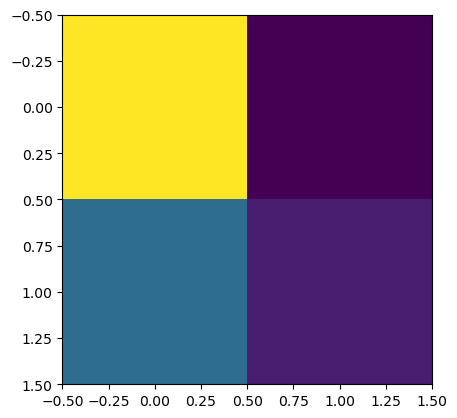

In [22]:
plt.imshow(cm)

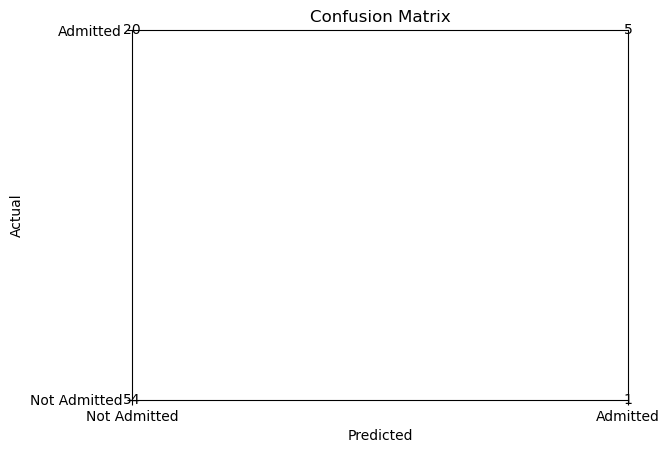

In [24]:
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Not Admitted", "Admitted"])
plt.yticks([0, 1], ["Not Admitted", "Admitted"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

In [25]:
# Feature coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print("\nModel Coefficients:")
print(coefficients)


Model Coefficients:
  Feature  Coefficient
0     gre     0.002321
1     gpa     0.813807
2  rank_2    -0.363204
3  rank_3    -0.992501
4  rank_4    -0.886848
